In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# Zero shot

## WhatsApp

In [10]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/wpp/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/wpp/amostra_classificada_manus_zero_shot_wpp.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_manus'
df_llm = df_llm.rename(columns={"prejudice_label": "rotulo_manus"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_manus"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/wpp/wpp_comparado_zero_shot.csv", index=False, encoding="utf-8")

print(" Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


 Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.



 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.8264 ± 0.0157
Precision: 0.8826 ± 0.0199
Recall: 0.7533 ± 0.0257
F1: 0.8125 ± 0.0184
Auc: 0.8264 ± 0.0154


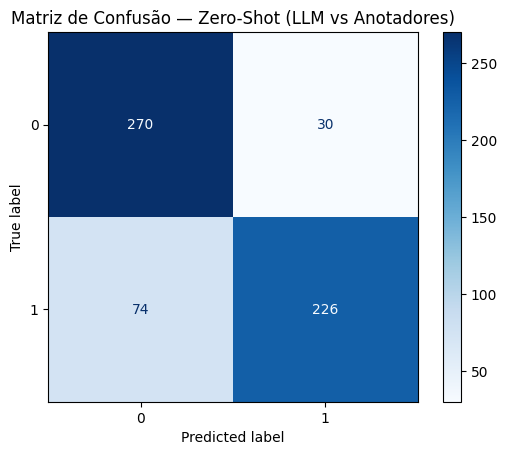

In [11]:

# --- Leitura dos dados ---
df = pd.read_csv("./resultados/wpp/wpp_comparado_zero_shot.csv")

# Converte para inteiro e remove valores ausentes
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_manus"] = pd.to_numeric(df["rotulo_manus"], errors="coerce")
df = df.dropna(subset=["preconceito", "rotulo_manus"])

y_true = df["preconceito"].values
y_pred = df["rotulo_manus"].values

# --- Bootstrap das métricas ---
n_bootstrap = 1000
rng = np.random.default_rng(42)

metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "auc": []}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# --- Resultados médios ---
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)

# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão — Zero-Shot (LLM vs Anotadores)")
plt.savefig("./resultados/wpp/matriz_confusao_zero_shot_wpp.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Salva as métricas ---
with open("./resultados/wpp/metricas_avaliacao_zeroShot_wpp.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")

    f.write("\nMatriz de Confusão:\n")
    f.write(str(cm))


## Telegram

In [7]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/telegram/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/telegram/amostra_classificada_manus_zero_shot_telegram.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_manus'
df_llm = df_llm.rename(columns={"label": "rotulo_manus"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_manus"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/telegram/telegram_comparado_zero_shot.csv", index=False, encoding="utf-8")

print(" Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


 Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


In [8]:
df_combinado['rotulo_manus'].value_counts()

rotulo_manus
1    343
0    257
Name: count, dtype: int64


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.7753 ± 0.0172
Precision: 0.7412 ± 0.0235
Recall: 0.8468 ± 0.0212
F1: 0.7902 ± 0.0178
Auc: 0.7753 ± 0.0170


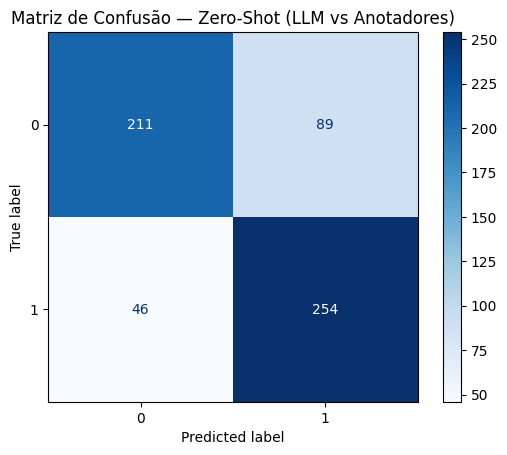

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --- Leitura dos dados ---
df = pd.read_csv("./resultados/telegram/telegram_comparado_zero_shot.csv")

# Converte para inteiro e remove valores ausentes
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_manus"] = pd.to_numeric(df["rotulo_manus"], errors="coerce")
df = df.dropna(subset=["preconceito", "rotulo_manus"])

y_true = df["preconceito"].values
y_pred = df["rotulo_manus"].values

# --- Bootstrap das métricas ---
n_bootstrap = 1000
rng = np.random.default_rng(42)

metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "auc": []}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# --- Resultados médios ---
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)

# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão — Zero-Shot (LLM vs Anotadores)")
plt.savefig("./resultados/telegram/matriz_confusao_zero_shot_telegram.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Salva as métricas ---
with open("./resultados/telegram/metricas_avaliacao_zeroShot_telegram.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")

    f.write("\nMatriz de Confusão:\n")
    f.write(str(cm))


# Few Shot

## WhatsApp

In [9]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/wpp/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/wpp/few_shot_manus_wpp_amostra_balanceada_rotulada.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_manus'
df_llm = df_llm.rename(columns={"label": "rotulo_manus"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_manus"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/wpp/wpp_comparado_few_shot.csv", index=False, encoding="utf-8")

print(" Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


 Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


In [10]:
df_combinado['rotulo_manus'].value_counts()

rotulo_manus
0    350
1    250
Name: count, dtype: int64


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.5927 ± 0.0201
Precision: 0.6119 ± 0.0298
Recall: 0.5087 ± 0.0290
F1: 0.5551 ± 0.0251
Auc: 0.5927 ± 0.0196


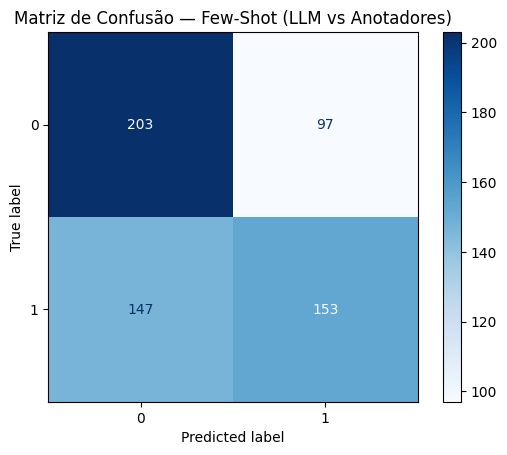

In [11]:


# --- Leitura dos dados ---
df = pd.read_csv("./resultados/wpp/wpp_comparado_few_shot.csv")

# Converte para inteiro e remove valores ausentes
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_manus"] = pd.to_numeric(df["rotulo_manus"], errors="coerce")
df = df.dropna(subset=["preconceito", "rotulo_manus"])

y_true = df["preconceito"].values
y_pred = df["rotulo_manus"].values

# --- Bootstrap das métricas ---
n_bootstrap = 1000
rng = np.random.default_rng(42)

metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "auc": []}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# --- Resultados médios ---
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)

# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão — Few-Shot (LLM vs Anotadores)")
plt.savefig("./resultados/wpp/matriz_confusao_few_shot_wpp.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Salva as métricas ---
with open("./resultados/wpp/metricas_avaliacao_fewShot_telegram.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")

    f.write("\nMatriz de Confusão:\n")
    f.write(str(cm))


## Telegram

# Role Prompting

## WhatsApp

## Telegram

In [3]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/telegram/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/telegram/rotulada_role_prompting_manus_telegram.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_manus'
df_llm = df_llm.rename(columns={"rotulo": "rotulo_manus"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_manus"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/telegram/telegram_comparado_role_prompting.csv", index=False, encoding="utf-8")

print(" Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


 Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.



 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.8231 ± 0.0151
Precision: 0.8145 ± 0.0219
Recall: 0.8371 ± 0.0206
F1: 0.8254 ± 0.0162
Auc: 0.8231 ± 0.0151


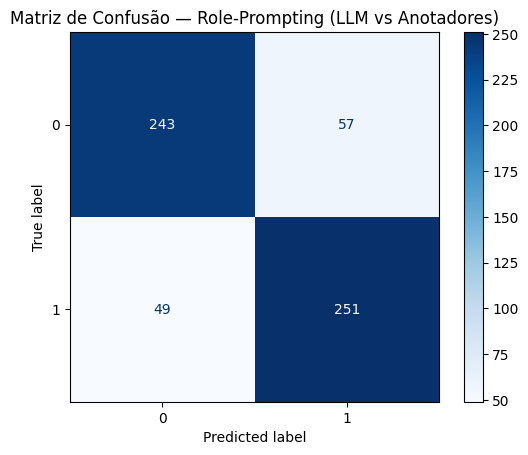

In [4]:


# --- Leitura dos dados ---
df = pd.read_csv("./resultados/telegram/telegram_comparado_role_prompting.csv")

# Converte para inteiro e remove valores ausentes
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_manus"] = pd.to_numeric(df["rotulo_manus"], errors="coerce")
df = df.dropna(subset=["preconceito", "rotulo_manus"])

y_true = df["preconceito"].values
y_pred = df["rotulo_manus"].values

# --- Bootstrap das métricas ---
n_bootstrap = 1000
rng = np.random.default_rng(42)

metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "auc": []}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# --- Resultados médios ---
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)

# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão — Role-Prompting (LLM vs Anotadores)")
plt.savefig("./resultados/telegram/matriz_confusao_zero_shot_telegram.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Salva as métricas ---
with open("./resultados/telegram/metricas_avaliacao_role_prompting_telegram.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")

    f.write("\nMatriz de Confusão:\n")
    f.write(str(cm))
